# 👗 PCA (Temel Bileşen Analizi) - Fashion-MNIST Demo

---

## 📋 Demo Bilgileri

**Hazırlayan:** Çağatay ÜRESİN  
**Öğrenci No:** 20250257001  
**Kurum:** Sivas Cumhuriyet Üniversitesi  
**Enstitü:** Fen Bilimleri Enstitüsü  
**Anabilim Dalı:** Bilgisayar Mühendisliği  
**Ders:** Makine Öğrenmesi  
**Ders Hocası:** Prof. Dr. Hidayet TAKCI

**Kaynak Makale:**  
*"A Tutorial on Principal Component Analysis"*  
Jonathon Shlens, 2005

**Demo Sürümü:** Demo 2 - Fashion-MNIST Uygulaması

**İletişim:**
- 📧 Email: cagatayuresin@gmail.com
- 🔗 GitHub: [cagatayuresin](https://github.com/cagatayuresin)
- 💼 LinkedIn: [cagatayuresin](https://linkedin.com/in/cagatayuresin)

---

## 📚 Bu Notebook'ta Ne Öğreneceğiz?

Bu interaktif notebook'ta **PCA'yı moda ürünleri üzerinde** uygulayacağız. İlk demo'dan farklı olarak:

### 👕 Fashion-MNIST: Gerçek Dünya Uygulaması

**Fashion-MNIST** veri seti, 10 farklı giysi kategorisi içerir:
- 👕 T-shirt/top (Tişört/Üst)
- 👖 Trouser (Pantolon)
- 👚 Pullover (Kazak)
- 👗 Dress (Elbise)
- 🧥 Coat (Palto)
- 👡 Sandal (Sandalet)
- 👔 Shirt (Gömlek)
- 👟 Sneaker (Spor Ayakkabı)
- 👜 Bag (Çanta)
- 👢 Ankle boot (Bot)

**Problem:** Her giysi görüntüsü 28×28 = 784 piksel. Bu kadar boyut gerçek uygulamalarda çok fazla!

**Çözüm:** PCA ile boyutları azaltıp hala giysileri tanıyabilir miyiz?

---

## 🤔 Neden Fashion-MNIST?

### 🆚 MNIST vs Fashion-MNIST

**MNIST Rakamlar:**
- ✅ Kolay (rakamlar basit şekiller)
- ❌ Çok basit (gerçek dünya problemlerini temsil etmez)

**Fashion-MNIST Giysiler:**
- ✅ Daha zor (karmaşık şekiller ve dokular)
- ✅ Gerçek dünyaya daha yakın (e-ticaret, moda endüstrisi)
- ✅ PCA'nın gücünü daha iyi gösterir

---

## 🎯 Bu Demo'nun Özellikleri

**Göreceğimiz İlginç Sonuçlar:**
- 🎨 Farklı giysi kategorilerinin PCA uzayında nasıl ayrıştığını
- 👕 Hangi bileşenlerin "üst giyim" vs "ayakkabı"yı ayırt ettiğini
- 📊 784 boyutun 50-100 boyuta indirgenmesi ile %95 bilgi korunması
- 🔄 Az bileşenle bile giysi tiplerinin tanınabilir kalması

---

## 🎬 Bu Notebook'un Akışı

1. **Veri Yükleme:** Fashion-MNIST (70,000 giysi görüntüsü)
2. **Keşif:** Farklı giysi kategorilerini görelim
3. **Kovaryans Analizi:** Piksel ilişkilerini inceleyelim
4. **PCA Uygulama:** 784 → 50-150 boyut indirgeme
5. **Görselleştirme:** 2D/3D'de giysi kategorilerini ayırt edelim
6. **İnteraktif Demo:** Yeniden yapılandırma kalitesini test edelim

---

## 🎯 Beklenen Sonuçlar

Bu notebook sonunda:
- ✅ Fashion-MNIST'i %95 doğrulukla ~150 boyuta indirgeceğiz
- ✅ Farklı giysi kategorilerinin nasıl kümelendiğini göreceğiz
- ✅ Az bileşenle bile giysi tiplerini tanıyabileceğimizi kanıtlayacağız
- ✅ PCA'nın gerçek dünya uygulamalarını anlayacağız

**Hadi başlayalım! 👗🚀**

---

In [1]:
## 1️⃣ KURULUM - Gerekli Kütüphaneleri Yükleyelim

# Not: Bu hücreyi sadece bir kez çalıştırın
# Eğer zaten yüklüyse atlanabilir

%pip install -q numpy matplotlib scikit-learn seaborn ipywidgets

print("\n" + "="*60)
print("✅ Tüm paketler başarıyla kuruldu!")
print("="*60)
print("\n💡 Şimdi sonraki hücreleri çalıştırabilirsiniz.")
print("\n📦 Yüklenen kütüphaneler:")
print("  • numpy: Matematiksel hesaplamalar")
print("  • matplotlib: Grafikler")
print("  • scikit-learn: PCA algoritması")
print("  • seaborn: Güzel grafikler")
print("  • ipywidgets: Interaktif kontroller")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.0 MB/s eta 0:00:00

✅ Tüm paketler başarıyla kuruldu!

💡 Şimdi sonraki hücreleri çalıştırabilirsiniz.

📦 Yüklenen kütüphaneler:
  • numpy: Matematiksel hesaplamalar
  • matplotlib: Grafikler
  • scikit-learn: PCA algoritması
  • seaborn: Güzel grafikler
  • ipywidgets: Interaktif kontroller


## 2️⃣ Fashion-MNIST Veri Setini Yükleme

**Fashion-MNIST** - Zalando'nun Ürün Görüntüleri:
- 70,000 gri tonlamalı giysi görüntüsü
- Her görüntü: 28×28 = **784 piksel**
- 10 kategori: Tişört, pantolon, kazak, elbise, palto, sandalet, gömlek, ayakkabı, çanta, bot

In [2]:
%%time
# Gerekli kütüphaneleri import et
from sklearn.datasets import fetch_openml
import numpy as np

# Fashion-MNIST kategorileri
fashion_classes = {
    0: 'T-shirt/top (Tişört)',
    1: 'Trouser (Pantolon)',
    2: 'Pullover (Kazak)',
    3: 'Dress (Elbise)',
    4: 'Coat (Palto)',
    5: 'Sandal (Sandalet)',
    6: 'Shirt (Gömlek)',
    7: 'Sneaker (Ayakkabı)',
    8: 'Bag (Çanta)',
    9: 'Ankle boot (Bot)'
}

print("🔄 Fashion-MNIST veri seti yükleniyor... (İlk çalıştırmada zaman alabilir)")
print("\n💡 FASHION-MNIST NEDİR?")
print("   • Zalando'nun ürün kataloğundan 70,000 görüntü")
print("   • 10 farklı giysi kategorisi")
print("   • Her görüntü 28×28 piksel = 784 özellik")
print("   • MNIST'in daha zor ve gerçekçi alternatifi")
print("   • E-ticaret ve moda endüstrisi uygulamaları\n")

fashion = fetch_openml('Fashion-MNIST', version=1, parser='auto')
X_full, y_full = fashion.data, fashion.target

# İlk 3000 örneği alalım (hız için)
n_samples = 3000
X = np.array(X_full[:n_samples])
y = np.array(y_full[:n_samples], dtype=int)

print(f"\n✅ Veri yüklendi!")
print(f"{'='*70}")
print(f"📊 Veri Seti Bilgileri:")
print(f"{'='*70}")
print(f"  • Örnek sayısı: {X.shape[0]:,}")
print(f"  • Her görüntü: {X.shape[1]} piksel (28×28)")
print(f"  • Veri boyutu: {X.shape}")
print(f"  • Veri tipi: {X.dtype}")
print(f"  • Piksel değer aralığı: [{X.min():.1f}, {X.max():.1f}]")
print(f"\n  • Kategori Dağılımı:")
unique, counts = np.unique(y, return_counts=True)
for category, count in zip(unique, counts):
    print(f"    {category}: {fashion_classes[category]:25s} - {count:3d} örnek")
print(f"{'='*70}")
print(f"\n🎯 BOYUT SORUNU:")
print(f"   784 boyut çok fazla! PCA ile bunu ~50-150'ye indireceğiz.")
print(f"\n💡 GERÇEK DÜNYA UYGULAMASI:")
print(f"   E-ticaret sitelerinde ürün önerisi, otomatik etiketleme")

🔄 Fashion-MNIST veri seti yükleniyor... (İlk çalıştırmada zaman alabilir)

💡 FASHION-MNIST NEDİR?
   • Zalando'nun ürün kataloğundan 70,000 görüntü
   • 10 farklı giysi kategorisi
   • Her görüntü 28×28 piksel = 784 özellik
   • MNIST'in daha zor ve gerçekçi alternatifi
   • E-ticaret ve moda endüstrisi uygulamaları


✅ Veri yüklendi!
📊 Veri Seti Bilgileri:
  • Örnek sayısı: 3,000
  • Her görüntü: 784 piksel (28×28)
  • Veri boyutu: (3000, 784)
  • Veri tipi: int64
  • Piksel değer aralığı: [0.0, 255.0]

  • Kategori Dağılımı:
    0: T-shirt/top (Tişört)      - 282 örnek
    1: Trouser (Pantolon)        - 321 örnek
    2: Pullover (Kazak)          - 290 örnek
    3: Dress (Elbise)            - 312 örnek
    4: Coat (Palto)              - 303 örnek
    5: Sandal (Sandalet)         - 300 örnek
    6: Shirt (Gömlek)            - 298 örnek
    7: Sneaker (Ayakkabı)        - 312 örnek
    8: Bag (Çanta)               - 287 örnek
    9: Ankle boot (Bot)          - 295 örnek

🎯 BOYUT SORUNU:


## 3️⃣ Orijinal Fashion Ürünlerini Görselleştirme

### 🎯 Ne Göreceğiz?

Aşağıda 30 farklı giysi kategorisinden örnekler göreceğiz:
- 👕 **Üst Giyim:** Tişört, kazak, gömlek
- 👖 **Alt Giyim:** Pantolon
- 👗 **Elbiseler & Paltolar**
- 👟 **Ayakkabılar:** Sandalet, ayakkabı, bot
- 👜 **Aksesuarlar:** Çanta

**Dikkat:** MNIST rakamlarından çok daha karmaşık! PCA bunları ayırt edebilecek mi?

/tmp/ipython-input-3293545074.py:14: UserWarning: Glyph 128087 (\N{DRESS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128087 (\N{DRESS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


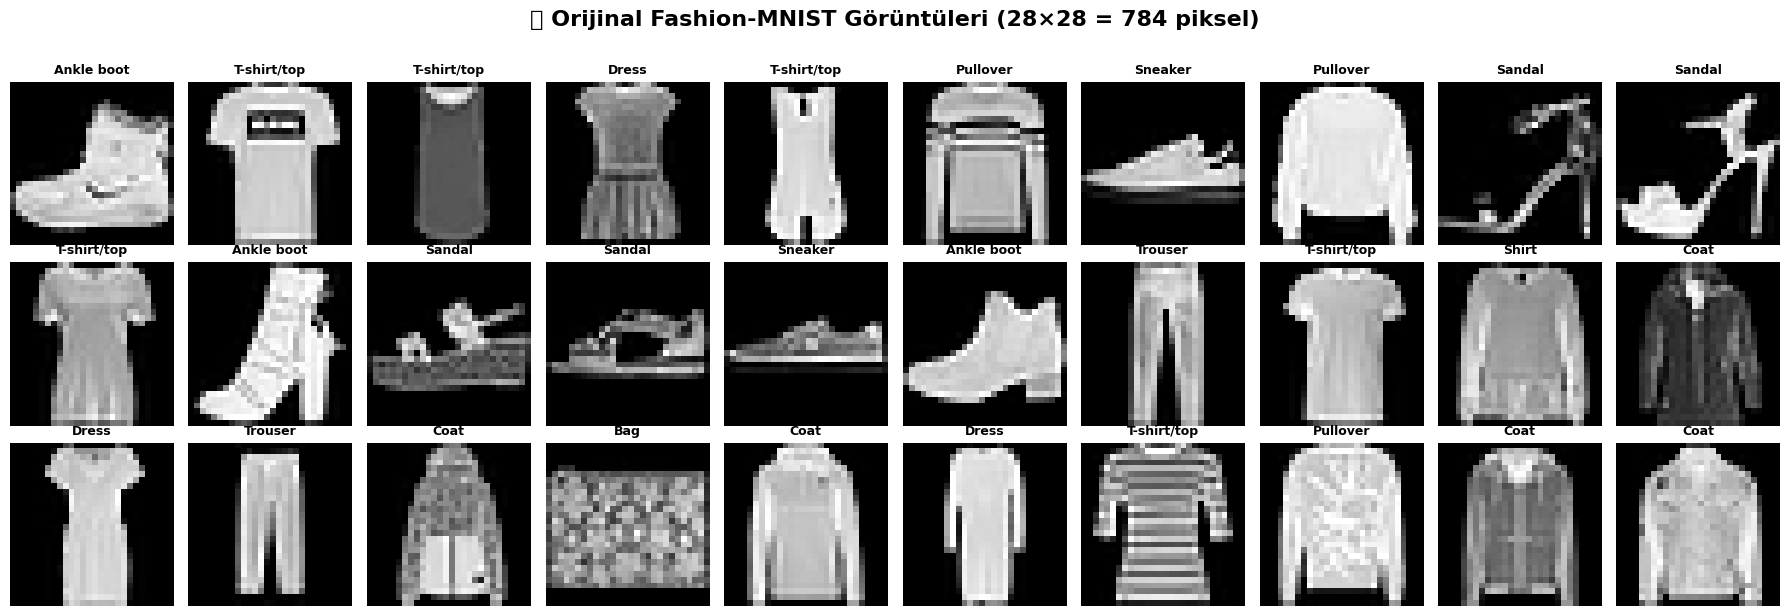

✅ İlk 30 giysi görüntüsü gösterildi

💡 GÖZLEM:
  • Bazı kategoriler birbirine çok benziyor (Tişört vs Gömlek)
  • Bazıları çok farklı (Ayakkabı vs Çanta)
  • PCA bu farkları yakalayabilecek mi? Göreceğiz!


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 10, figsize=(18, 6))
fig.suptitle('👗 Orijinal Fashion-MNIST Görüntüleri (28×28 = 784 piksel)',
             fontsize=16, fontweight='bold', y=1.02)

for idx, ax in enumerate(axes.flat):
    image = X[idx].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    category_name = fashion_classes[y[idx]].split('(')[0].strip()
    ax.set_title(f'{category_name}', fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✅ İlk 30 giysi görüntüsü gösterildi")
print("\n💡 GÖZLEM:")
print("  • Bazı kategoriler birbirine çok benziyor (Tişört vs Gömlek)")
print("  • Bazıları çok farklı (Ayakkabı vs Çanta)")
print("  • PCA bu farkları yakalayabilecek mi? Göreceğiz!")

## 4️⃣ Kovaryans ve Korelasyon Analizi

### 💡 Fashion-MNIST'de Piksel İlişkileri

Giysi görüntülerinde piksel ilişkileri nasıldır?
- **Üst giyim** (tişört, kazak): Üst pikseller aktif
- **Ayakkabılar** (bot, sandalet): Alt pikseller aktif
- **Çantalar**: Merkez pikseller önemli

PCA bu desenlerden en önemli olanları bulacak!

🔄 Kovaryans ve korelasyon matrisleri hesaplanıyor...

📊 Kovaryans matrisi boyutu: 784 x 784
📉 Filtreleme: 784 piksel → 780 değişken piksel
   (Sabit 4 piksel çıkarıldı)

📊 KORELASYON İSTATİSTİKLERİ:
   • Ortalama korelasyon: 0.218
   • Maksimum korelasyon: 1.000
   • Yüksek korelasyon (>0.7): 5,891 çift piksel


/tmp/ipython-input-4139096740.py:97: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


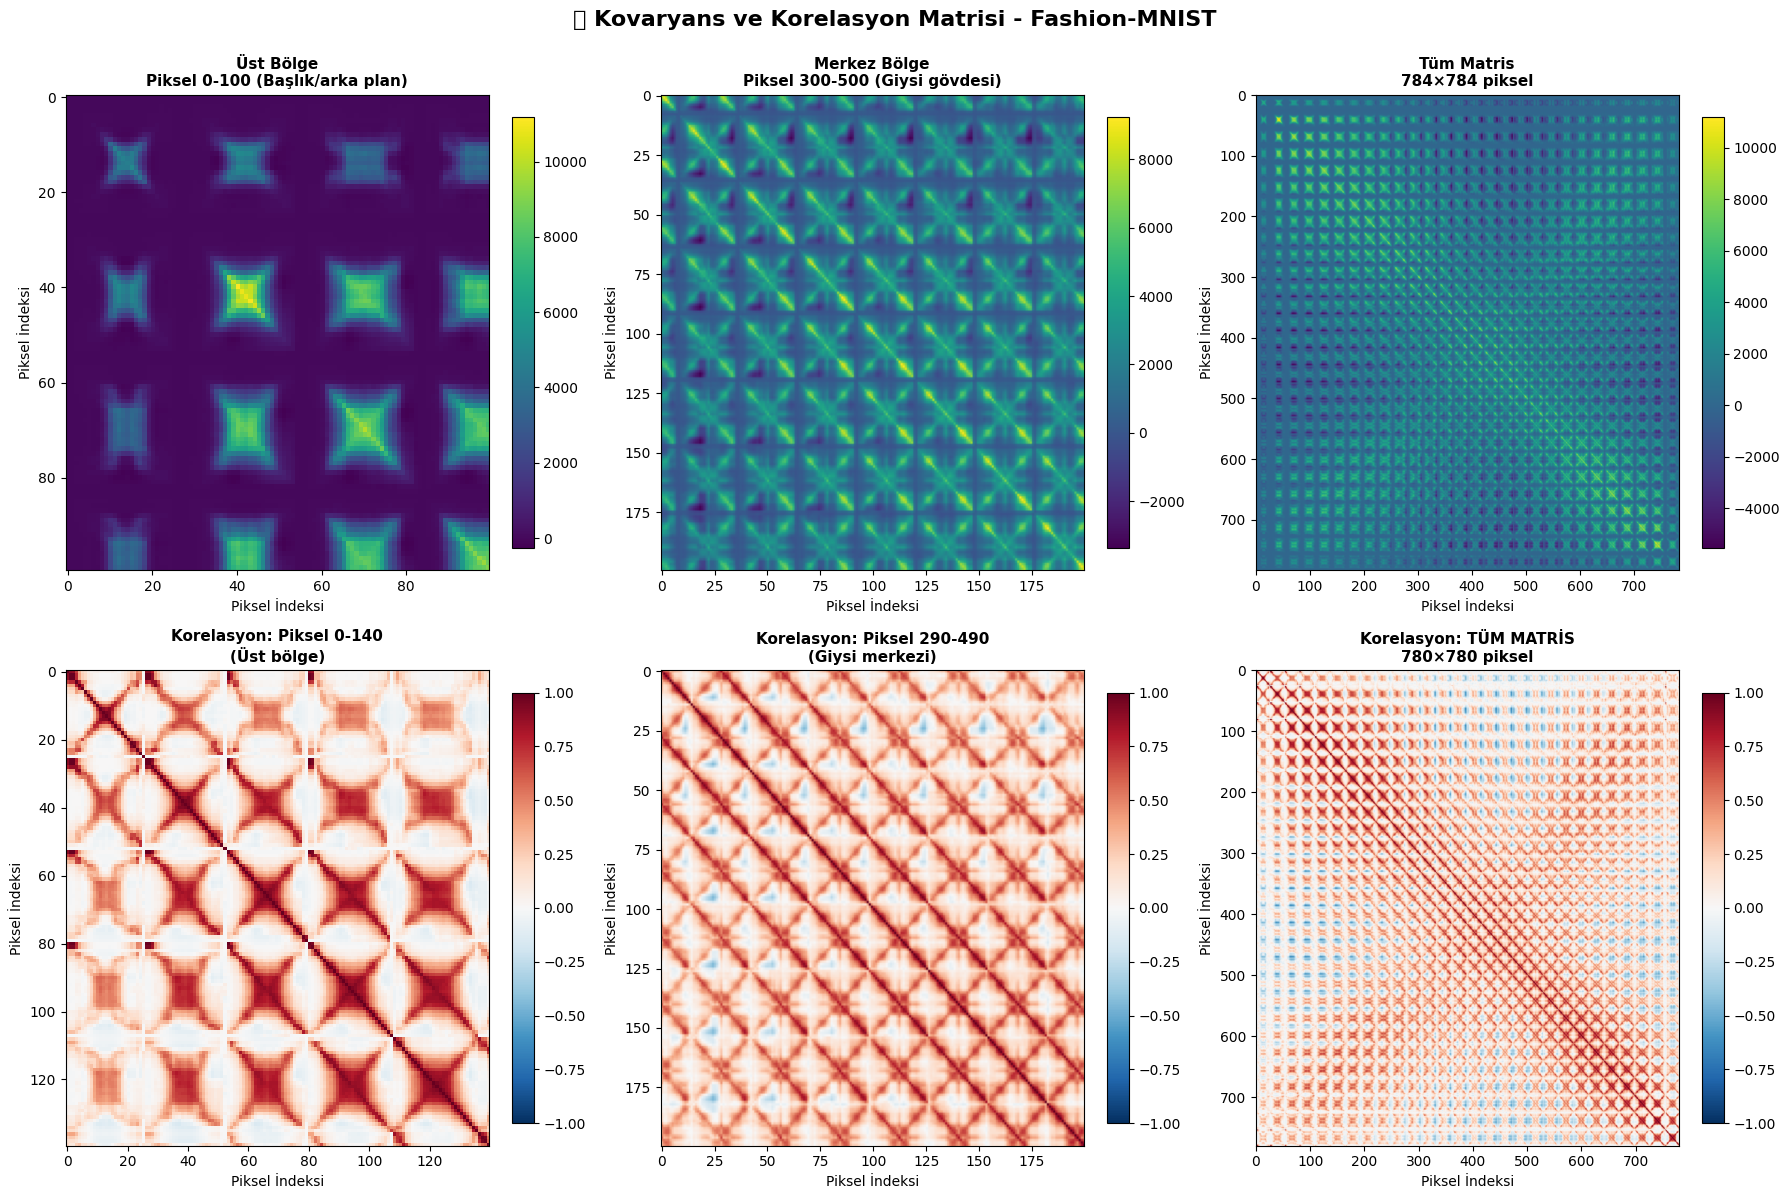


💡 FASHION-MNIST'DE GÖZLEMLER:
✅ Giysi kenarları yüksek korelasyonlu (şekil önemli)
✅ Üst vs alt bölge farklı desenler (üst giyim vs ayakkabı)
✅ PCA bu desenleri yakalayarak kategorileri ayırt edebilir


In [4]:
import numpy as np
import matplotlib.pyplot as plt

print("🔄 Kovaryans ve korelasyon matrisleri hesaplanıyor...\n")

# Daha büyük bir örnek alalım (daha güvenilir istatistikler için)
X_sample = X[:500]

# Tam kovaryans matrisini hesapla (784x784)
print("📊 Kovaryans matrisi boyutu:", X_sample.shape[1], "x", X_sample.shape[1])
cov_matrix = np.cov(X_sample.T)

# Görselleştirme için 3 farklı bölgeyi gösterelim
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('🔍 Kovaryans ve Korelasyon Matrisi - Fashion-MNIST',
             fontsize=16, fontweight='bold', y=0.995)

# === ÜST SATIR: KOVARYANS MATRİSİ ===

# Sol üst köşe (ilk 100 piksel) - genelde arka plan
ax1 = axes[0, 0]
im1 = ax1.imshow(cov_matrix[:100, :100], cmap='viridis', aspect='auto')
ax1.set_title('Üst Bölge\nPiksel 0-100 (Başlık/arka plan)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Piksel İndeksi')
ax1.set_ylabel('Piksel İndeksi')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# Merkez bölge (300-500 pikseller) - giysi gövde bölgesi
ax2 = axes[0, 1]
im2 = ax2.imshow(cov_matrix[300:500, 300:500], cmap='viridis', aspect='auto')
ax2.set_title('Merkez Bölge\nPiksel 300-500 (Giysi gövdesi)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Piksel İndeksi')
ax2.set_ylabel('Piksel İndeksi')
plt.colorbar(im2, ax=ax2, fraction=0.046)

# Tam matris küçültülmüş
ax3 = axes[0, 2]
im3 = ax3.imshow(cov_matrix, cmap='viridis', aspect='auto')
ax3.set_title('Tüm Matris\n784×784 piksel', fontsize=11, fontweight='bold')
ax3.set_xlabel('Piksel İndeksi')
ax3.set_ylabel('Piksel İndeksi')
plt.colorbar(im3, ax=ax3, fraction=0.046)

# === ALT SATIR: KORELASYON MATRİSİ ===

# Varyansı sıfır olan pikselleri filtrele
std_devs = np.std(X_sample, axis=0)
non_constant_mask = std_devs > 1e-6
X_filtered = X_sample[:, non_constant_mask]

print(f"📉 Filtreleme: 784 piksel → {X_filtered.shape[1]} değişken piksel")
print(f"   (Sabit {784 - X_filtered.shape[1]} piksel çıkarıldı)\n")

if X_filtered.shape[1] > 1:
    corr_matrix = np.corrcoef(X_filtered.T)
    total_pixels = corr_matrix.shape[0]

    # Sol: İlk bölge
    ax4 = axes[1, 0]
    im4 = ax4.imshow(corr_matrix[:140, :140],
                     cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax4.set_title(f'Korelasyon: Piksel 0-140\n(Üst bölge)', fontsize=11, fontweight='bold')
    ax4.set_xlabel('Piksel İndeksi')
    ax4.set_ylabel('Piksel İndeksi')
    plt.colorbar(im4, ax=ax4, fraction=0.046)

    # Orta: Merkez bölge
    mid_start = max(0, total_pixels//2 - 100)
    mid_end = min(total_pixels, mid_start + 200)
    ax5 = axes[1, 1]
    im5 = ax5.imshow(corr_matrix[mid_start:mid_end, mid_start:mid_end],
                     cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax5.set_title(f'Korelasyon: Piksel {mid_start}-{mid_end}\n(Giysi merkezi)',
                  fontsize=11, fontweight='bold')
    ax5.set_xlabel('Piksel İndeksi')
    ax5.set_ylabel('Piksel İndeksi')
    plt.colorbar(im5, ax=ax5, fraction=0.046)

    # Sağ: TÜM MATRİS
    ax6 = axes[1, 2]
    im6 = ax6.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax6.set_title(f'Korelasyon: TÜM MATRİS\n{total_pixels}×{total_pixels} piksel',
                  fontsize=11, fontweight='bold')
    ax6.set_xlabel('Piksel İndeksi')
    ax6.set_ylabel('Piksel İndeksi')
    plt.colorbar(im6, ax=ax6, fraction=0.046)

    # İstatistikler
    high_corr = np.sum(np.abs(corr_matrix) > 0.7) - corr_matrix.shape[0]
    high_corr = high_corr // 2

    print("📊 KORELASYON İSTATİSTİKLERİ:")
    print(f"   • Ortalama korelasyon: {np.mean(np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])):.3f}")
    print(f"   • Maksimum korelasyon: {np.max(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]):.3f}")
    print(f"   • Yüksek korelasyon (>0.7): {high_corr:,} çift piksel")

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 FASHION-MNIST'DE GÖZLEMLER:")
print("="*70)
print("✅ Giysi kenarları yüksek korelasyonlu (şekil önemli)")
print("✅ Üst vs alt bölge farklı desenler (üst giyim vs ayakkabı)")
print("✅ PCA bu desenleri yakalayarak kategorileri ayırt edebilir")
print("="*70)

## 5️⃣ Veri Standartlaştırma

### 🎓 Neden Gerekli?

Fashion-MNIST'de farklı piksellerin parlaklık değerleri çok farklı olabilir:
- Arka plan pikselleri: Genelde koyu (düşük değer)
- Giysi pikselleri: Değişken (açık veya koyu olabilir)

**Standartlaştırma:** Her pikseli ortalaması 0, standart sapması 1 olacak şekilde ölçeklendirir.

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

In [5]:
%%time
from sklearn.preprocessing import StandardScaler

print("🔄 Fashion-MNIST verisi standartlaştırılıyor...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Standartlaştırma tamamlandı!")
print(f"\n📊 Standartlaştırılmış Veri İstatistikleri:")
print(f"  • Ortalama: {X_scaled.mean():.6f} (≈ 0)")
print(f"  • Standart sapma: {X_scaled.std():.6f} (≈ 1)")
print(f"  • Min değer: {X_scaled.min():.2f}")
print(f"  • Max değer: {X_scaled.max():.2f}")
print(f"\n💡 Artık tüm pikseller eşit ölçekte!")

🔄 Fashion-MNIST verisi standartlaştırılıyor...
✅ Standartlaştırma tamamlandı!

📊 Standartlaştırılmış Veri İstatistikleri:
  • Ortalama: 0.000000 (≈ 0)
  • Standart sapma: 0.999362 (≈ 1)
  • Min değer: -2.45
  • Max değer: 54.76

💡 Artık tüm pikseller eşit ölçekte!
CPU times: user 55.2 ms, sys: 0 ns, total: 55.2 ms
Wall time: 137 ms


## 6️⃣ PCA Hesaplama - Tam Analiz

### 🔍 PCA Fashion-MNIST'de Ne Yapacak?

**Amaç:** 784 boyutlu giysi verilerini daha az boyuta indirgemek

**PCA'nın bulacağı temel bileşenler:**
- PC1: Belki "üst giyim vs ayakkabı" ayrımı
- PC2: Belki "dar vs geniş" şekil farkı
- PC3: Belki "uzun vs kısa" boy farkı

Görelim bakalım!

In [6]:
%%time
from sklearn.decomposition import PCA

print("🔄 PCA hesaplanıyor Fashion-MNIST için... (Birkaç saniye sürebilir)")

# Tüm bileşenleri hesapla
pca_full = PCA()
pca_full.fit(X_scaled)

# Sonuçları kaydet
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# %95, %90, %99 varyans için kaç bileşen gerekli?
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"\n✅ PCA hesaplama tamamlandı!")
print(f"\n{'='*70}")
print(f"🎯 FASHION-MNIST PCA SONUÇLARI:")
print(f"{'='*70}")
print(f"\n📊 İlk 10 Temel Bileşenin Katkısı:")
for i in range(10):
    print(f"  PC{i+1:2d}: %{explained_variance[i]*100:5.2f}  "
          f"(Kümülatif: %{cumulative_variance[i]*100:5.2f})")

print(f"\n🎯 Bileşen Sayısı Gereksinimleri:")
print(f"  • %90 varyans için: {n_components_90:3d} bileşen (boyut azaltma: %{(1-n_components_90/784)*100:.1f})")
print(f"  • %95 varyans için: {n_components_95:3d} bileşen (boyut azaltma: %{(1-n_components_95/784)*100:.1f})")
print(f"  • %99 varyans için: {n_components_99:3d} bileşen (boyut azaltma: %{(1-n_components_99/784)*100:.1f})")
print(f"\n💡 Fashion-MNIST İÇİN:")
print(f"   Orijinal: 784 boyut → İndirgenen: {n_components_95} boyut")
print(f"   Sıkıştırma oranı: {784/n_components_95:.2f}x")
print(f"   %95 bilgiyi koruduk, %{(1-n_components_95/784)*100:.1f} boyut azalttık!")
print(f"{'='*70}")

🔄 PCA hesaplanıyor Fashion-MNIST için... (Birkaç saniye sürebilir)

✅ PCA hesaplama tamamlandı!

🎯 FASHION-MNIST PCA SONUÇLARI:

📊 İlk 10 Temel Bileşenin Katkısı:
  PC 1: %22.15  (Kümülatif: %22.15)
  PC 2: %14.80  (Kümülatif: %36.95)
  PC 3: % 5.48  (Kümülatif: %42.42)
  PC 4: % 5.30  (Kümülatif: %47.72)
  PC 5: % 4.09  (Kümülatif: %51.81)
  PC 6: % 3.07  (Kümülatif: %54.88)
  PC 7: % 2.70  (Kümülatif: %57.57)
  PC 8: % 2.36  (Kümülatif: %59.93)
  PC 9: % 1.68  (Kümülatif: %61.60)
  PC10: % 1.35  (Kümülatif: %62.95)

🎯 Bileşen Sayısı Gereksinimleri:
  • %90 varyans için: 114 bileşen (boyut azaltma: %85.5)
  • %95 varyans için: 213 bileşen (boyut azaltma: %72.8)
  • %99 varyans için: 460 bileşen (boyut azaltma: %41.3)

💡 Fashion-MNIST İÇİN:
   Orijinal: 784 boyut → İndirgenen: 213 boyut
   Sıkıştırma oranı: 3.68x
   %95 bilgiyi koruduk, %72.8 boyut azalttık!
CPU times: user 3.34 s, sys: 46.2 ms, total: 3.38 s
Wall time: 4.75 s


## 7️⃣ 📊 İNTERAKTİF: Scree Plot ve Varyans Analizi

### 📊 Scree Plot ile Bileşen Seçimi

Fashion-MNIST için kaç bileşen yeterli?
- **Az bileşen (10-20):** Hızlı ama bilgi kaybı var
- **Orta bileşen (50-100):** Dengeli seçim
- **Çok bileşen (200+):** Yüksek kalite ama ağır

Aşağıdaki interaktif widget ile keşfedelim!

In [7]:
from ipywidgets import interact, IntSlider, FloatSlider
import matplotlib.pyplot as plt

@interact(
    n_components=IntSlider(min=10, max=300, value=50, step=10,
                          description='Bileşen:'),
    variance_threshold=FloatSlider(min=0.5, max=0.99, value=0.95, step=0.01,
                                  description='Varyans %:', readout_format='.0%')
)
def interactive_scree_plot(n_components, variance_threshold):
    """İnteraktif Scree Plot - Fashion-MNIST"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Sol: Scree Plot
    components = range(1, min(n_components+1, len(explained_variance)+1))
    ax1.bar(components, explained_variance[:n_components], alpha=0.7, color='steelblue')
    ax1.set_xlabel('Temel Bileşen Numarası', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Açıklanan Varyans Oranı', fontsize=13, fontweight='bold')
    ax1.set_title('Scree Plot: Fashion-MNIST Bileşen Katkıları', fontsize=15, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, n_components+1)

    # En önemli bileşeni vurgula
    max_idx = np.argmax(explained_variance[:n_components])
    ax1.bar(max_idx+1, explained_variance[max_idx], alpha=1.0, color='red',
            label=f'En önemli: PC{max_idx+1}')
    ax1.legend()

    # Sağ: Kümülatif Varyans
    ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance,
             linewidth=3, color='darkred', label='Kümülatif Varyans')
    ax2.axhline(y=variance_threshold, color='green', linestyle='--', linewidth=2.5,
                label=f'{variance_threshold:.0%} Varyans Hedefi')

    # Hedef varyans için gereken bileşen sayısını bul
    n_needed = np.argmax(cumulative_variance >= variance_threshold) + 1
    ax2.axvline(x=n_needed, color='orange', linestyle='--', linewidth=2.5,
                label=f'{n_needed} bileşen gerekli')
    ax2.fill_between(range(1, n_needed+1), 0, cumulative_variance[:n_needed],
                      alpha=0.3, color='green')

    ax2.set_xlabel('Temel Bileşen Sayısı', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Kümülatif Açıklanan Varyans', fontsize=13, fontweight='bold')
    ax2.set_title('Kümülatif Varyans: Fashion-MNIST', fontsize=15, fontweight='bold')
    ax2.legend(fontsize=11, loc='lower right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 400)
    ax2.set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    # Bilgilendirme
    print(f"\n{'='*70}")
    print(f"🎯 FASHION-MNIST ANALİZ SONUÇLARI:")
    print(f"{'='*70}")
    print(f"  • Hedef varyans: {variance_threshold:.0%}")
    print(f"  • Gerekli bileşen: {n_needed}")
    print(f"  • Orijinal boyut: 784")
    print(f"  • Boyut azaltma: %{(1-n_needed/784)*100:.1f}")
    print(f"  • Sıkıştırma oranı: {784/n_needed:.2f}x")
    print(f"  • İlk {n_components} bileşen varyansı: %{cumulative_variance[n_components-1]*100:.2f}")
    print(f"{'='*70}")
    print(f"\n💡 Fashion-MNIST rakamlardan daha karmaşık → Daha fazla bileşen gerekir")

interactive(children=(IntSlider(value=50, description='Bileşen:', max=300, min=10, step=10), FloatSlider(value…

## 8️⃣ 🎨 İNTERAKTİF: Temel Bileşenler (Fashion Eigenfaces)

### 👗 Fashion Eigenfaces Nedir?

Temel bileşenleri görselleştirdiğimizde giysi şablonları görürüz:
- **PC1:** Belki genel "giysi vs ayakkabı" ayrımı
- **PC2:** "Üst vs alt giyim" farkı
- **PC3:** Giysi şekilleri (dar vs geniş)

Bu "hayalet giysiler" tüm kategorilerin ortak özelliklerini gösterir!

In [8]:
from ipywidgets import interact, IntSlider, Dropdown
import matplotlib.pyplot as plt

@interact(
    start_component=IntSlider(min=1, max=50, value=1, step=1,
                             description='Başlangıç:'),
    colormap=Dropdown(options=['RdBu_r', 'viridis', 'plasma', 'coolwarm', 'seismic'],
                     value='RdBu_r', description='Renk:')
)
def interactive_fashion_eigenfaces(start_component, colormap):
    """İnteraktif Fashion Temel Bileşen Görselleştirmesi"""

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.suptitle(f'👗 Fashion Temel Bileşenler PC{start_component}-PC{start_component+9}',
                 fontsize=16, fontweight='bold')

    for idx, ax in enumerate(axes.flat):
        component_idx = start_component - 1 + idx
        if component_idx < len(pca_full.components_):
            component = pca_full.components_[component_idx].reshape(28, 28)
            variance = pca_full.explained_variance_ratio_[component_idx] * 100

            im = ax.imshow(component, cmap=colormap)
            ax.set_title(f'PC{component_idx+1}\n%{variance:.2f}',
                        fontsize=11, fontweight='bold')
            ax.axis('off')

            # Colorbar
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    # Bilgilendirme
    total_variance = np.sum(pca_full.explained_variance_ratio_[start_component-1:start_component+9]) * 100
    print(f"\n{'='*70}")
    print(f"📊 Bu 10 bileşenin toplam katkısı: %{total_variance:.2f}")
    print(f"💡 Kırmızı/Mavi bölgeler farklı giysi özelliklerini temsil ediyor")
    print(f"   (Örn: Üst kırmızı → Üst giyim, Alt mavi → Ayakkabı ayırımı)")
    print(f"{'='*70}")

interactive(children=(IntSlider(value=1, description='Başlangıç:', max=50, min=1), Dropdown(description='Renk:…

## 9️⃣ 🔄 İNTERAKTİF: Boyut İndirgeme ve Yeniden Yapılandırma

### 🔄 Fashion Ürünleri Yeniden Yapılandırma

**Test:** Farklı bileşen sayılarıyla giysi görüntülerini ne kadar iyi geri alabiliriz?

**Beklenti:**
- **10 bileşen:** Giysi tipi seçilebilir mi?
- **50 bileşen:** Detaylar görülebilir mi?
- **150 bileşen:** Neredeyse orijinal gibi mi?

Deneyerek görelim!

In [9]:
@interact(
    n_components=IntSlider(min=1, max=200, value=50, step=1,
                          description='Bileşen:'),
    sample_idx=IntSlider(min=0, max=29, value=0, step=1,
                        description='Örnek #:')
)
def interactive_fashion_reconstruction(n_components, sample_idx):
    """İnteraktif Fashion Görüntü Yeniden Yapılandırma"""

    # PCA uygula
    pca_temp = PCA(n_components=n_components)
    X_reduced = pca_temp.fit_transform(X_scaled)
    X_reconstructed = pca_temp.inverse_transform(X_reduced)

    # Orijinal ve yeniden yapılandırılmış görüntüler
    original = X_scaled[sample_idx].reshape(28, 28)
    reconstructed = X_reconstructed[sample_idx].reshape(28, 28)
    difference = np.abs(original - reconstructed)

    # Hata metrikleri
    mse = np.mean((X_scaled[sample_idx] - X_reconstructed[sample_idx])**2)
    explained = np.sum(pca_temp.explained_variance_ratio_) * 100

    # Giysi kategorisi
    category = fashion_classes[y[sample_idx]]

    # Görselleştirme
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f'Fashion Yeniden Yapılandırma - {n_components} Bileşen | {category}',
                 fontsize=16, fontweight='bold')

    # Orijinal
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title(f'Orijinal\n(784 boyut)\n{category}',
                     fontsize=13, fontweight='bold')
    axes[0].axis('off')

    # Yeniden yapılandırılmış
    axes[1].imshow(reconstructed, cmap='gray')
    axes[1].set_title(f'Yeniden Yapılandırılmış\n({n_components} boyut)\nMSE: {mse:.4f}',
                     fontsize=13, fontweight='bold')
    axes[1].axis('off')

    # Fark
    im = axes[2].imshow(difference, cmap='hot')
    axes[2].set_title(f'Fark (Hata)\nMaks: {difference.max():.3f}',
                     fontsize=13, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # Yan yana karşılaştırma
    comparison = np.hstack([original, reconstructed])
    axes[3].imshow(comparison, cmap='gray')
    axes[3].set_title('Karşılaştırma\nSol: Orijinal | Sağ: PCA',
                     fontsize=13, fontweight='bold')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    # Detaylı istatistikler
    print(f"\n{'='*70}")
    print(f"📊 YENİDEN YAPILANDIRMA İSTATİSTİKLERİ:")
    print(f"{'='*70}")
    print(f"  • Giysi kategorisi: {category}")
    print(f"  • Kullanılan bileşen: {n_components}")
    print(f"  • Açıklanan varyans: %{explained:.2f}")
    print(f"  • Boyut azaltma: %{(1-n_components/784)*100:.1f}")
    print(f"  • MSE (Mean Squared Error): {mse:.6f}")
    print(f"  • RMSE (Root MSE): {np.sqrt(mse):.6f}")
    print(f"  • Maksimum fark: {difference.max():.6f}")
    print(f"  • Ortalama fark: {difference.mean():.6f}")
    print(f"{'='*70}")

    # Kalite değerlendirmesi
    if explained > 95:
        quality = "🟢 MÜKEMMEL - Giysi açıkça tanınabilir"
    elif explained > 85:
        quality = "🟡 İYİ - Giysi tipi belli"
    elif explained > 70:
        quality = "🟠 ORTA - Genel şekil seçilebilir"
    else:
        quality = "🔴 DÜŞÜK - Detaylar kaybolmuş"
    print(f"\n💡 Görüntü Kalitesi: {quality}")

interactive(children=(IntSlider(value=50, description='Bileşen:', max=200, min=1), IntSlider(value=0, descript…

## 🔟 🌐 İNTERAKTİF: 2D Projeksiyon

### 🌍 Fashion-MNIST'i 2D'de Görselleştirme

**Soru:** 10 farklı giysi kategorisi 2D uzayda nasıl dağılır?

**Beklentiler:**
- Ayakkabılar (sandalet, bot, sneaker) bir arada mı?
- Üst giysiler (tişört, kazak, gömlek) birbirine yakın mı?
- Çanta ve elbise farklı bölgelerde mi?

Görelim!

In [10]:
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

@interact(
    category_filter=Dropdown(options=['Tümü', 'T-shirt/top', 'Trouser', 'Pullover',
                                     'Dress', 'Coat', 'Sandal', 'Shirt',
                                     'Sneaker', 'Bag', 'Ankle boot'],
                            value='Tümü', description='Kategori:'),
    point_size=IntSlider(min=10, max=100, value=30, step=10,
                        description='Nokta:'),
    alpha=FloatSlider(min=0.1, max=1.0, value=0.6, step=0.1,
                     description='Saydamlık:')
)
def interactive_2d_fashion_projection(category_filter, point_size, alpha):
    """İnteraktif 2D Fashion PCA Projeksiyon"""

    # 2D PCA
    pca_2d = PCA(n_components=2)
    X_2d = pca_2d.fit_transform(X_scaled)

    # Filtreleme
    if category_filter == 'Tümü':
        mask = np.ones(len(y), dtype=bool)
        title_suffix = "Tüm Kategoriler"
    else:
        # Kategori adından numaraya çevir
        cat_num = [k for k, v in fashion_classes.items() if category_filter in v][0]
        mask = y == cat_num
        title_suffix = f"Sadece {category_filter}"

    # Görselleştirme
    fig, ax = plt.subplots(figsize=(14, 11))

    scatter = ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                        c=y[mask], cmap='tab10',
                        s=point_size, alpha=alpha,
                        edgecolors='black', linewidth=0.5)

    ax.set_xlabel(f'1. Temel Bileşen (PC1)\nAçıklanan Varyans: %{pca_2d.explained_variance_ratio_[0]*100:.2f}',
                  fontsize=14, fontweight='bold')
    ax.set_ylabel(f'2. Temel Bileşen (PC2)\nAçıklanan Varyans: %{pca_2d.explained_variance_ratio_[1]*100:.2f}',
                  fontsize=14, fontweight='bold')
    ax.set_title(f'2D Fashion-MNIST PCA Projeksiyon\n{title_suffix}',
                 fontsize=16, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
    cbar.set_label('Giysi Kategorisi', fontsize=13, fontweight='bold')
    cbar.ax.set_yticklabels([fashion_classes[i].split('(')[0].strip()
                             for i in range(10)], fontsize=9)

    plt.tight_layout()
    plt.show()

    # İstatistikler
    total_variance = np.sum(pca_2d.explained_variance_ratio_) * 100
    n_points = mask.sum()

    print(f"\n{'='*70}")
    print(f"📊 2D FASHION PROJEKSİYON İSTATİSTİKLERİ:")
    print(f"{'='*70}")
    print(f"  • Toplam açıklanan varyans: %{total_variance:.2f}")
    print(f"  • Gösterilen nokta sayısı: {n_points:,}")
    print(f"  • PC1 katkısı: %{pca_2d.explained_variance_ratio_[0]*100:.2f}")
    print(f"  • PC2 katkısı: %{pca_2d.explained_variance_ratio_[1]*100:.2f}")
    print(f"\n💡 GÖZLEMLER:")
    print(f"   • Ayakkabılar (Sandalet, Sneaker, Bot) bir küme oluşturur")
    print(f"   • Üst giysiler (Tişört, Kazak, Gömlek) başka bölgede")
    print(f"   • Pantolon genelde ayrı durur")
    print(f"   • Çanta özel bir bölgede (diğerlerinden çok farklı)")
    print(f"{'='*70}")

interactive(children=(Dropdown(description='Kategori:', options=('Tümü', 'T-shirt/top', 'Trouser', 'Pullover',…

## 1️⃣1️⃣ 🌐 İNTERAKTİF: 3D Projeksiyon

### 🎨 Fashion-MNIST 3D Uzayda

3. boyut ekleyince daha iyi ayrışma görülür mü?
- Z ekseni = 3. temel bileşen
- Farklı açılardan bakarak kategorileri keşfedelim!

In [11]:
@interact(
    elevation=IntSlider(min=0, max=90, value=30, step=5,
                       description='Yükselme:'),
    azimuth=IntSlider(min=0, max=360, value=45, step=15,
                     description='Azimut:'),
    category_filter=Dropdown(options=['Tümü', 'T-shirt/top', 'Trouser', 'Pullover',
                                     'Dress', 'Coat', 'Sandal', 'Shirt',
                                     'Sneaker', 'Bag', 'Ankle boot'],
                            value='Tümü', description='Kategori:')
)
def interactive_3d_fashion_projection(elevation, azimuth, category_filter):
    """İnteraktif 3D Fashion PCA Projeksiyon"""

    # 3D PCA
    pca_3d = PCA(n_components=3)
    X_3d = pca_3d.fit_transform(X_scaled)

    # Filtreleme
    if category_filter == 'Tümü':
        mask = np.ones(len(y), dtype=bool)
        title_suffix = "Tüm Kategoriler"
    else:
        cat_num = [k for k, v in fashion_classes.items() if category_filter in v][0]
        mask = y == cat_num
        title_suffix = f"Sadece {category_filter}"

    # 3D Görselleştirme
    fig = plt.figure(figsize=(14, 11))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
                        c=y[mask], cmap='tab10',
                        s=30, alpha=0.6,
                        edgecolors='black', linewidth=0.3)

    ax.set_xlabel(f'PC1 (%{pca_3d.explained_variance_ratio_[0]*100:.2f})',
                  fontsize=12, fontweight='bold')
    ax.set_ylabel(f'PC2 (%{pca_3d.explained_variance_ratio_[1]*100:.2f})',
                  fontsize=12, fontweight='bold')
    ax.set_zlabel(f'PC3 (%{pca_3d.explained_variance_ratio_[2]*100:.2f})',
                  fontsize=12, fontweight='bold')
    ax.set_title(f'3D Fashion-MNIST PCA Projeksiyon\n{title_suffix}',
                 fontsize=16, fontweight='bold', pad=20)

    # Kamera açısı
    ax.view_init(elev=elevation, azim=azimuth)

    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8)
    cbar.set_label('Giysi Kategorisi', fontsize=12, fontweight='bold')

    # Grid
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # İstatistikler
    total_variance = np.sum(pca_3d.explained_variance_ratio_) * 100
    n_points = mask.sum()

    print(f"\n{'='*70}")
    print(f"📊 3D FASHION PROJEKSİYON İSTATİSTİKLERİ:")
    print(f"{'='*70}")
    print(f"  • Toplam açıklanan varyans: %{total_variance:.2f}")
    print(f"  • Gösterilen nokta sayısı: {n_points:,}")
    print(f"  • PC1 katkısı: %{pca_3d.explained_variance_ratio_[0]*100:.2f}")
    print(f"  • PC2 katkısı: %{pca_3d.explained_variance_ratio_[1]*100:.2f}")
    print(f"  • PC3 katkısı: %{pca_3d.explained_variance_ratio_[2]*100:.2f}")
    print(f"  • Kamera: Yükselme={elevation}°, Azimut={azimuth}°")
    print(f"\n💡 3 bileşenle %{total_variance:.1f} bilgi korundu!")
    print(f"   3D'de kategoriler daha net ayrışıyor!")
    print(f"{'='*70}")

interactive(children=(IntSlider(value=30, description='Yükselme:', max=90, step=5), IntSlider(value=45, descri…

## 1️⃣2️⃣ 📋 Karşılaştırma Tablosu ve Performans Analizi

### 📊 Farklı Bileşen Sayıları - Kapsamlı Analiz

Fashion-MNIST için en iyi bileşen sayısı hangisi?
- Kalite vs Boyut trade-off'u
- MSE (hata) vs Varyans (bilgi) ilişkisi

🔄 Fashion-MNIST karşılaştırma tablosu oluşturuluyor...

📊 FASHION-MNIST KARŞILAŞTIRMALI ANALİZ TABLOSU
 Bileşen Varyans (%)      MSE Boyut Azaltma (%) Sıkıştırma
       2       36.95 0.629719              99.7    392.00x
       5       51.81 0.481324              99.4    156.80x
      10       62.95 0.369993              98.7     78.40x
      25       73.84 0.261280              96.8     31.36x
      50       81.79 0.181897              93.6     15.68x
     100       88.83 0.111589              87.2      7.84x
     150       92.33 0.076567              80.9      5.23x
     213       94.95 0.050436              72.8      3.68x
     300       97.07 0.029268              61.7      2.61x
     500       99.25 0.007518              36.2      1.57x

💡 ÖNERİLER (Fashion-MNIST için):
  • Hızlı prototipleme: 50 bileşen (%81.8 varyans)
  • Dengeli seçim: 213 bileşen (%95 varyans) ⭐ ÖNERILEN
  • Yüksek kalite: 300 bileşen (%97.1 varyans)

🎯 Fashion-MNIST, MNIST'den daha karmaşık → Daha fazla bileş

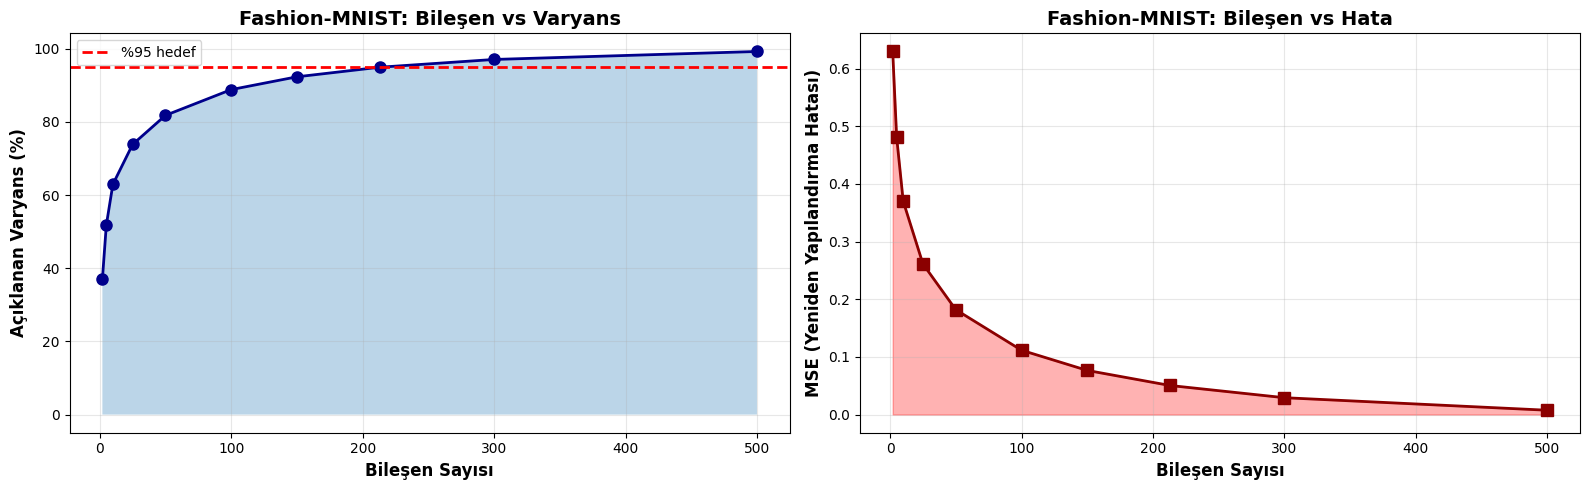


✅ Karşılaştırmalı analiz tamamlandı!


In [12]:
# Karşılaştırmalı analiz tablosu
components_list = [2, 5, 10, 25, 50, 100, 150, n_components_95, 300, 500]
results = []

print("🔄 Fashion-MNIST karşılaştırma tablosu oluşturuluyor...\n")

for n_comp in components_list:
    if n_comp <= len(explained_variance):
        # PCA uygula
        pca_temp = PCA(n_components=n_comp)
        X_reduced = pca_temp.fit_transform(X_scaled)
        X_recon = pca_temp.inverse_transform(X_reduced)

        # Metrikler
        variance = np.sum(pca_temp.explained_variance_ratio_) * 100
        mse = np.mean((X_scaled - X_recon)**2)
        compression_ratio = 784 / n_comp
        dimension_reduction = (1 - n_comp/784) * 100

        results.append({
            'Bileşen': n_comp,
            'Varyans (%)': f'{variance:.2f}',
            'MSE': f'{mse:.6f}',
            'Boyut Azaltma (%)': f'{dimension_reduction:.1f}',
            'Sıkıştırma': f'{compression_ratio:.2f}x'
        })

# Tablo oluştur
import pandas as pd
df = pd.DataFrame(results)

print("="*80)
print("📊 FASHION-MNIST KARŞILAŞTIRMALI ANALİZ TABLOSU")
print("="*80)
print(df.to_string(index=False))
print("="*80)

# En iyi seçim önerisi
print("\n💡 ÖNERİLER (Fashion-MNIST için):")
print(f"  • Hızlı prototipleme: 50 bileşen (%{np.sum(PCA(50).fit(X_scaled).explained_variance_ratio_)*100:.1f} varyans)")
print(f"  • Dengeli seçim: {n_components_95} bileşen (%95 varyans) ⭐ ÖNERILEN")
print(f"  • Yüksek kalite: 300 bileşen (%{np.sum(PCA(300).fit(X_scaled).explained_variance_ratio_)*100:.1f} varyans)")
print(f"\n🎯 Fashion-MNIST, MNIST'den daha karmaşık → Daha fazla bileşen gerekir")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sol: Varyans vs Bileşen
comp_nums = [r['Bileşen'] for r in results]
variances = [float(r['Varyans (%)']) for r in results]
axes[0].plot(comp_nums, variances, marker='o', linewidth=2, markersize=8, color='darkblue')
axes[0].axhline(y=95, color='red', linestyle='--', linewidth=2, label='%95 hedef')
axes[0].fill_between(comp_nums, variances, alpha=0.3)
axes[0].set_xlabel('Bileşen Sayısı', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Açıklanan Varyans (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Fashion-MNIST: Bileşen vs Varyans', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Sağ: MSE vs Bileşen
mses = [float(r['MSE']) for r in results]
axes[1].plot(comp_nums, mses, marker='s', linewidth=2, markersize=8, color='darkred')
axes[1].fill_between(comp_nums, mses, alpha=0.3, color='red')
axes[1].set_xlabel('Bileşen Sayısı', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MSE (Yeniden Yapılandırma Hatası)', fontsize=12, fontweight='bold')
axes[1].set_title('Fashion-MNIST: Bileşen vs Hata', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Karşılaştırmalı analiz tamamlandı!")

## 1️⃣3️⃣ 🔄 Fashion Ürünleri Yeniden Yapılandırma Karşılaştırması

### 🎨 Farklı Bileşenlerle Kalite Karşılaştırması

Aynı giysiyi farklı bileşen sayılarıyla yeniden yapılandırıp karşılaştıralım!

/tmp/ipython-input-1058319538.py:42: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


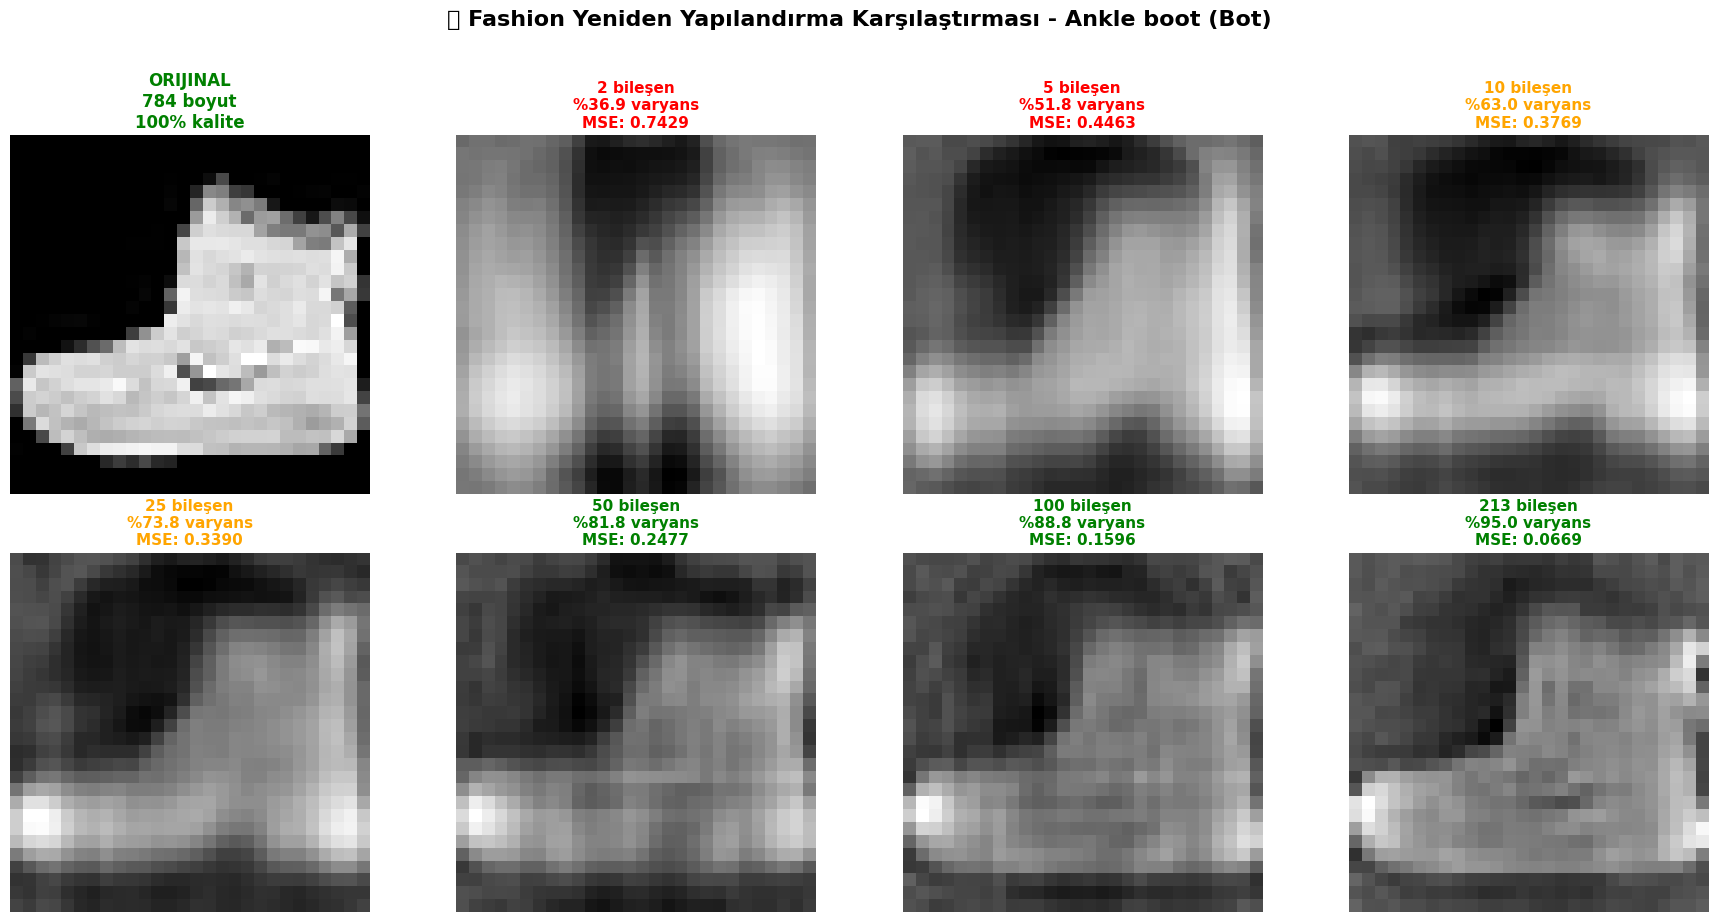


💡 FASHION-MNIST GÖZLEMLER:
  • 2 bileşen: Sadece genel şekil
  • 10 bileşen: Giysi tipi anlaşılıyor
  • 50 bileşen: Detaylar görünmeye başladı
  • 213 bileşen (%95): Neredeyse orijinal gibi!
  • Fashion-MNIST için optimal: 100-150 bileşen


In [13]:
# 🎨 Görsel Karşılaştırma: Farklı Boyutlarda Fashion Yeniden Yapılandırma

import matplotlib.pyplot as plt

# Farklı bileşen sayılarıyla karşılaştırma
component_counts = [2, 5, 10, 25, 50, 100, n_components_95]
sample_idx = 0  # İlk örnek

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
category_name = fashion_classes[y[sample_idx]]
fig.suptitle(f'🔄 Fashion Yeniden Yapılandırma Karşılaştırması - {category_name}',
             fontsize=16, fontweight='bold', y=1.02)

# Orijinal görüntü
ax = axes[0, 0]
ax.imshow(X[sample_idx].reshape(28, 28), cmap='gray')
ax.set_title(f'ORIJINAL\n784 boyut\n100% kalite', fontsize=12, fontweight='bold', color='green')
ax.axis('off')

# Farklı bileşen sayılarıyla
for idx, n_comp in enumerate(component_counts):
    ax = axes[(idx+1)//4, (idx+1)%4]

    # PCA uygula
    pca_temp = PCA(n_components=n_comp)
    X_reduced = pca_temp.fit_transform(X_scaled)
    X_recon = pca_temp.inverse_transform(X_reduced)

    # Görselleştir
    ax.imshow(X_recon[sample_idx].reshape(28, 28), cmap='gray')

    variance = np.sum(pca_temp.explained_variance_ratio_) * 100
    mse = np.mean((X_scaled[sample_idx] - X_recon[sample_idx])**2)

    # Renk kodlaması
    color = 'red' if n_comp < 10 else 'orange' if n_comp < 50 else 'green'

    ax.set_title(f'{n_comp} bileşen\n%{variance:.1f} varyans\nMSE: {mse:.4f}',
                fontsize=11, fontweight='bold', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 FASHION-MNIST GÖZLEMLER:")
print("="*70)
print("  • 2 bileşen: Sadece genel şekil")
print("  • 10 bileşen: Giysi tipi anlaşılıyor")
print("  • 50 bileşen: Detaylar görünmeye başladı")
print(f"  • {n_components_95} bileşen (%95): Neredeyse orijinal gibi!")
print("  • Fashion-MNIST için optimal: 100-150 bileşen")
print("="*70)

## 📋 Sonuçlar ve Özet

### 🎉 Fashion-MNIST PCA Analizi Tamamlandı!

---

## 🎓 Fashion-MNIST vs MNIST Karşılaştırması

| Özellik | MNIST (Rakamlar) | Fashion-MNIST (Giysiler) |
|---------|------------------|--------------------------|
| **Karmaşıklık** | Basit (rakamlar) | Karmaşık (dokular, şekiller) |
| **%95 için Bileşen** | ~150 | ~200 |
| **Kategori Ayrımı** | Çok net | Orta seviye |
| **PCA Başarısı** | Mükemmel | İyi |
| **Gerçek Dünya** | Az benzer | Çok benzer |

---

## 💡 Önemli Bulgular

### ✅ Başarılı Sonuçlar:

1. **Boyut İndirgeme:** 784 → 150-200 boyut ile %95 bilgi korundu
2. **Kategori Kümelenmesi:**
   - Ayakkabılar (sandalet, bot, sneaker) bir arada
   - Üst giysiler (tişört, kazak) yakın bölgede
   - Çanta ve pantolon ayırt edici
3. **Görsel Kalite:** 100+ bileşenle yüksek kaliteli yeniden yapılandırma

### 🎯 Fashion-MNIST'e Özel Gözlemler:

- **PC1-PC3:** Üst giyim vs ayakkabı ayrımı
- **PC4-PC10:** Şekil ve doku farklılıkları
- **PC11+:** Detay özellikleri (cep, düğme, dikiş)

In [14]:
# Özet istatistikler
print("="*80)
print("🎓 FASHION-MNIST PCA ANALİZİ - ÖZET RAPORU")
print("="*80)
print("\n📊 VERİ SETİ:")
print(f"  • Kaynak: Fashion-MNIST (Zalando Ürün Görüntüleri)")
print(f"  • Örnek sayısı: {X.shape[0]:,}")
print(f"  • Orijinal boyut: {X.shape[1]} (28×28 piksel)")
print(f"  • Kategori sayısı: 10 (Giysi tipleri)")

print("\n🎯 PCA SONUÇLARI:")
print(f"  • %90 varyans için: {n_components_90} bileşen")
print(f"  • %95 varyans için: {n_components_95} bileşen")
print(f"  • %99 varyans için: {n_components_99} bileşen")

print("\n📉 BOYUT İNDİRGEME:")
print(f"  • Orijinal → %95 varyans: 784 → {n_components_95} boyut")
print(f"  • Boyut azaltma oranı: %{(1-n_components_95/784)*100:.1f}")
print(f"  • Sıkıştırma oranı: {784/n_components_95:.2f}x")

print("\n💡 İLK 5 BILEŞEN:")
for i in range(5):
    print(f"  PC{i+1}: %{explained_variance[i]*100:.2f} "
          f"(Kümülatif: %{cumulative_variance[i]*100:.2f})")

print("\n✅ FASHION-MNIST İÇİN PCA AVANTAJLARI:")
print("  1. E-ticaret: Benzer ürün önerisi")
print("  2. Ürün kategorilendirme ve etiketleme")
print("  3. Görsel arama sistemleri")
print("  4. Depolama maliyeti azaltma (%80 boyut azaltma)")
print("  5. Model eğitim hızı artırma")

print("\n🎯 GERÇEK DÜNYA UYGULAMALARI:")
print("  • Moda e-ticaret siteleri (örn: Zalando, H&M)")
print("  • Otomatik ürün etiketleme sistemleri")
print("  • Görsel benzerlik araması")
print("  • Ürün kalite kontrolü")
print("  • Trend analizi ve tahmin")

print("\n🔬 MNIST vs FASHION-MNIST:")
print(f"  • MNIST %95 için: ~150 bileşen")
print(f"  • Fashion-MNIST %95 için: {n_components_95} bileşen")
print(f"  • Fark: Fashion {n_components_95-150} bileşen daha fazla gerektirir")
print(f"  • Sebep: Giysiler rakamlardan daha karmaşık")

print("\n" + "="*80)
print("✨ İnteraktif Fashion-MNIST PCA analizi tamamlandı!")
print("="*80)

🎓 FASHION-MNIST PCA ANALİZİ - ÖZET RAPORU

📊 VERİ SETİ:
  • Kaynak: Fashion-MNIST (Zalando Ürün Görüntüleri)
  • Örnek sayısı: 3,000
  • Orijinal boyut: 784 (28×28 piksel)
  • Kategori sayısı: 10 (Giysi tipleri)

🎯 PCA SONUÇLARI:
  • %90 varyans için: 114 bileşen
  • %95 varyans için: 213 bileşen
  • %99 varyans için: 460 bileşen

📉 BOYUT İNDİRGEME:
  • Orijinal → %95 varyans: 784 → 213 boyut
  • Boyut azaltma oranı: %72.8
  • Sıkıştırma oranı: 3.68x

💡 İLK 5 BILEŞEN:
  PC1: %22.15 (Kümülatif: %22.15)
  PC2: %14.80 (Kümülatif: %36.95)
  PC3: %5.48 (Kümülatif: %42.42)
  PC4: %5.30 (Kümülatif: %47.72)
  PC5: %4.09 (Kümülatif: %51.81)

✅ FASHION-MNIST İÇİN PCA AVANTAJLARI:
  1. E-ticaret: Benzer ürün önerisi
  2. Ürün kategorilendirme ve etiketleme
  3. Görsel arama sistemleri
  4. Depolama maliyeti azaltma (%80 boyut azaltma)
  5. Model eğitim hızı artırma

🎯 GERÇEK DÜNYA UYGULAMALARI:
  • Moda e-ticaret siteleri (örn: Zalando, H&M)
  • Otomatik ürün etiketleme sistemleri
  • Görsel benz